<div style="border: 5px solid black; padding: 20px; border-radius: 6px;">

## **Course:** DSC640 - Data Presentation and Visualization 
## **Name:** Tim Hollis  
## **Assignment:** Weeks 1 & 2 Assignment - Netflix Viewership 
## **Date:** 06/08/2026

---

**Reference**

Netflix. (n.d.). *Global Top 10* [Data set]. Tudum by Netflix. Retrieved June 7, 2026, from https://www.netflix.com/tudum/top10

</div>

### **Initial Setup**

In [1]:
# Loading Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import seaborn as sns

# Setting Display Options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Setting Visualization Formatting
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# Defining Colorblind-Safe Palette
royal_blue = '#4169E1'
purple = '#4B0082'
forest_green = '#228B22'
brand_palette = [royal_blue, purple, forest_green]
sns.set_palette(brand_palette)

# Loading Datasets
countries = pd.read_excel('all-weeks-countries-netflix.xlsx')
global_top10 = pd.read_excel('all-weeks-global-netflix.xlsx')
most_popular = pd.read_excel('most-popular-netflix.xlsx')

# Confirming Load and Structure
datasets = {'Countries': countries, 'Global': global_top10, 'Most Popular': most_popular}
for name, df in datasets.items():
    print(f'✅ {name} loaded: {df.shape[0]:,} rows and {df.shape[1]} columns')
    print(f'   Columns: {list(df.columns)}')
    print()

✅ Countries loaded: 272,260 rows and 8 columns
   Columns: ['country_name', 'country_iso2', 'week', 'category', 'weekly_rank', 'show_title', 'season_title', 'cumulative_weeks_in_top_10']

✅ Global loaded: 5,840 rows and 11 columns
   Columns: ['week', 'category', 'weekly_rank', 'show_title', 'season_title', 'weekly_hours_viewed', 'runtime', 'weekly_views', 'cumulative_weeks_in_top_10', 'is_staggered_launch', 'episode_launch_details']

✅ Most Popular loaded: 40 rows and 7 columns
   Columns: ['category', 'rank', 'show_title', 'season_title', 'hours_viewed_first_91_days', 'runtime', 'views_first_91_days']



### **Overview**

Netflix publishes a weekly Top 10 of its most-watched titles, both globally and by country, alongside an all-time most-popular list (Netflix, n.d.). This briefing draws on three of those published datasets to answer one question for the content investment committee: what separates a title that holds the Top 10 for months from one that spikes for a single week and disappears?

The three sources work together. The global file (5,840 rows) gives each title's weekly rank, category, hours viewed, runtime, and cumulative weeks in the Top 10. The countries file (272,260 rows) tracks rank and cumulative weeks within individual territories, which lets us measure how far a title travels rather than how loudly it launches. The most-popular file (40 rows) records the all-time biggest debuts by views in their first 91 days. One caveat runs through the analysis: Netflix switched its ranking metric on June 20, 2023, from total hours viewed to views (hours viewed divided by runtime, rounded to the nearest 100,000), so this briefing leans on cumulative weeks and 91-day views, which are reported consistently. The data is first-party and self-reported, the country lists cover selected territories, and neither is independently audited.

Treating weeks in the Top 10 as the measure of staying power, six visuals move from how rare longevity is, to which content types sustain it, to how far durable titles travel. The recommendation that follows is direct: **weight green-light and renewal decisions toward the profile that earns longevity and broad geographic reach, rather than chasing one-week viewership spikes.**

<hr style="page-break-before: always;">

### **Data Preparation**

The raw files store one row per title per week, so before visualizing we collapse them to one row per title. We key each title on its season where Netflix tracks one, falling back to the show title, then derive each title's longest run in the Top 10, its total hours viewed, and how many countries it charted in.

In [2]:
# Parsing Week Columns to Datetime
global_top10['week'] = pd.to_datetime(global_top10['week'])
countries['week'] = pd.to_datetime(countries['week'])

# Building a Unified Title Key (season where present, else show title)
def build_title_key(df):
    season = df['season_title'].fillna('').astype(str).str.strip()
    show = df['show_title'].fillna('').astype(str).str.strip()
    return season.where(season != '', show)

global_top10['title'] = build_title_key(global_top10)
countries['title'] = build_title_key(countries)

# Collapsing Global Data to One Row per Title
global_titles = (global_top10
                 .groupby('title', as_index=False)
                 .agg(show_title=('show_title', 'first'),
                      category=('category', 'first'),
                      max_weeks=('cumulative_weeks_in_top_10', 'max'),
                      total_hours_viewed=('weekly_hours_viewed', 'sum')))

# Measuring Global Reach from the Countries Data
country_reach = (countries
                 .groupby('title', as_index=False)
                 .agg(show_title=('show_title', 'first'),
                      countries_charted=('country_name', 'nunique')))

# Merging Reach and Longevity for Titles Present in Both Files
reach_vs_longevity = global_titles.merge(
    country_reach[['title', 'countries_charted']],
    on='title',
    how='inner')

# Confirming the Prepared Frames
print(f'✅ Global titles prepared: {global_titles.shape[0]:,} unique titles')
print(f'✅ Country reach prepared: {country_reach.shape[0]:,} unique titles')
print(f'✅ Reach and longevity merged: {reach_vs_longevity.shape[0]:,} titles in both files')
print()

# Previewing the Two Frames That Drive Most Visuals
display(global_titles.sort_values('max_weeks', ascending=False).head(3))
display(reach_vs_longevity.sort_values('max_weeks', ascending=False).head(3))

✅ Global titles prepared: 2,110 unique titles
✅ Country reach prepared: 7,865 unique titles
✅ Reach and longevity merged: 2,095 titles in both files



,title,show_title,category,max_weeks,total_hours_viewed
2078,"Yo soy Betty, la fea: Season 1","Yo soy Betty, la fea",TV (Non-English),30,297560000
280,Café con aroma de mujer: Season 1,Café con aroma de mujer,TV (Non-English),28,813480000
1021,Manifest: Season 1,Manifest,TV (English),25,637420000


,title,show_title,category,max_weeks,total_hours_viewed,countries_charted
2063,"Yo soy Betty, la fea: Season 1","Yo soy Betty, la fea",TV (Non-English),30,297560000,16
278,Café con aroma de mujer: Season 1,Café con aroma de mujer,TV (Non-English),28,813480000,19
1015,Manifest: Season 1,Manifest,TV (English),25,637420000,93


### **Visual 1: How Rare Is Staying Power?**

Before recommending that Netflix chase longevity, we should establish how uncommon it is. This view counts titles by the most weeks they ever spent in the global Top 10.

1. Summarize the distribution with the median run and the share of titles lasting three weeks or fewer.
2. Plot every title's peak weeks in the Top 10 as a histogram, with the median marked.
3. Read off how thin the long-running tail really is.

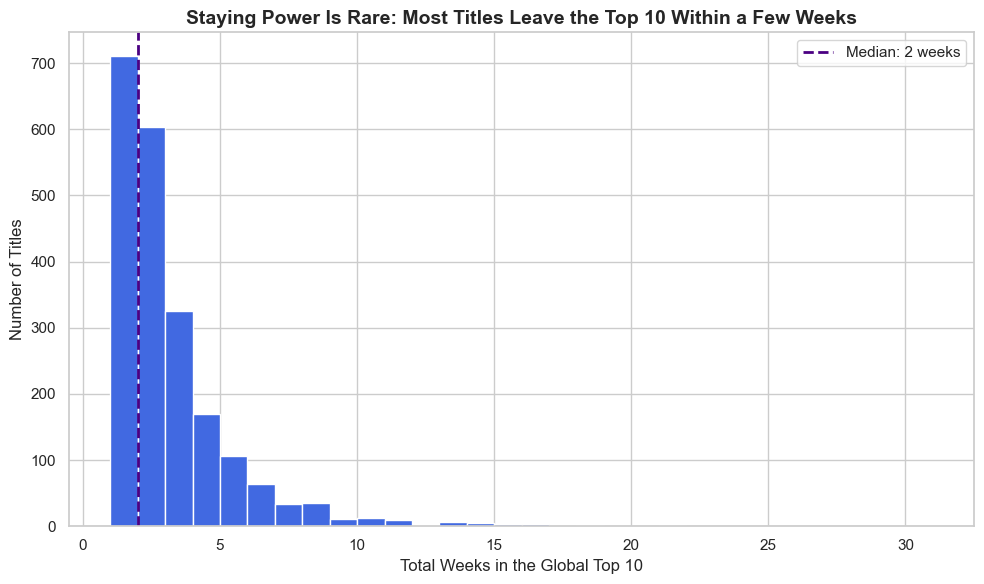

📊 Median run: 2 weeks in the Top 10
📉 77.8% of titles last 3 weeks or fewer
🏆 Only 52 titles ever reached 10 or more weeks


In [3]:
# Calculating Staying Power Summary Stats
median_weeks = global_titles['max_weeks'].median()
short_lived = (global_titles['max_weeks'] <= 3).mean() * 100
durable = (global_titles['max_weeks'] >= 10).sum()

# Plotting the Distribution of Weeks in the Top 10
fig, ax = plt.subplots()
ax.hist(global_titles['max_weeks'],
        bins=range(1, int(global_titles['max_weeks'].max()) + 2),
        color=royal_blue, edgecolor='white')
ax.axvline(median_weeks, color=purple, linestyle='--', linewidth=2,
           label=f'Median: {median_weeks:.0f} weeks')
ax.set_title('Staying Power Is Rare: Most Titles Leave the Top 10 Within a Few Weeks')
ax.set_xlabel('Total Weeks in the Global Top 10')
ax.set_ylabel('Number of Titles')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

# Narrating the Takeaway
print(f'📊 Median run: {median_weeks:.0f} weeks in the Top 10')
print(f'📉 {short_lived:.1f}% of titles last 3 weeks or fewer')
print(f'🏆 Only {durable:,} titles ever reached 10 or more weeks')

**Takeaway.** Staying power is the exception, not the rule. Half of all titles leave the global Top 10 within two weeks, and 77.8% are gone within three. Of the 2,110 titles that have ever charted, only 52, roughly one in forty, lasted ten weeks or longer. Endurance that rare is worth identifying deliberately, which is the case this briefing builds toward.

### **Visual 2: The Longevity Champions**

If staying power is rare, which titles achieved it, and what kind of content are they? This ranks the 15 longest-running titles and colors each by its content category.

1. Map each of the four content categories to a colorblind-safe color.
2. Select the 15 titles with the most total weeks in the Top 10.
3. Plot them as horizontal bars and summarize the category mix.

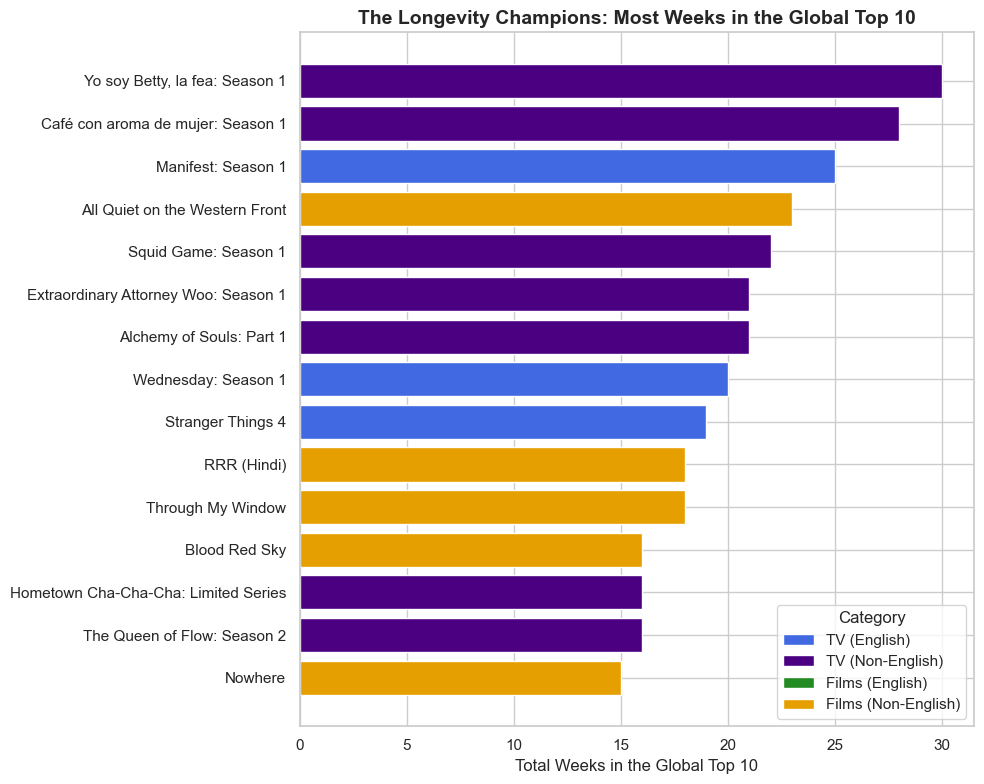

🏆 Category mix among the 15 longest-running titles:
   TV (Non-English): 7
   Films (Non-English): 5
   TV (English): 3


In [4]:
# Defining a Reusable Category Color Map (used here and in later visuals)
amber = '#E69F00'
category_colors = {'TV (English)': royal_blue,
                   'TV (Non-English)': purple,
                   'Films (English)': forest_green,
                   'Films (Non-English)': amber}

# Selecting the 15 Longest-Running Titles (ascending so the longest sits on top)
top_titles = (global_titles
              .sort_values('max_weeks', ascending=False)
              .head(15)
              .sort_values('max_weeks'))
bar_colors = top_titles['category'].map(category_colors).fillna('#999999')

# Plotting the Longevity Champions
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_titles['title'], top_titles['max_weeks'], color=bar_colors, edgecolor='white')
ax.set_title('The Longevity Champions: Most Weeks in the Global Top 10')
ax.set_xlabel('Total Weeks in the Global Top 10')
ax.set_ylabel('')

# Building a Category Legend
from matplotlib.patches import Patch
legend_items = [Patch(facecolor=color, label=cat) for cat, color in category_colors.items()]
ax.legend(handles=legend_items, title='Category', loc='lower right')

plt.tight_layout()
plt.show()

# Narrating the Takeaway
print('🏆 Category mix among the 15 longest-running titles:')
for cat, n in top_titles['category'].value_counts().items():
    print(f'   {cat}: {n}')

**Takeaway.** The titles that endure are not the splashy English-language films that dominate launch-week headlines. Twelve of the fifteen longest-running titles are non-English, ten of the fifteen are series rather than films, and not a single English-language film appears on the list. Telenovelas and international series, the kind of catalog that builds a loyal weekly audience, are what hold the Top 10 over time.

### **Visual 3: Which Content Sustains?**

Visual two showed the individual champions. This asks whether the pattern holds across all 2,110 titles. Because the distribution is so skewed, the median collapses to one or two weeks for every category and hides the differences, so we compare the average run and the share of each category that lasts five weeks or longer.

1. For each category, compute the average weeks in the Top 10 and the share of titles reaching five or more weeks.
2. Plot the average run by category.
3. Report the durability rate alongside it.

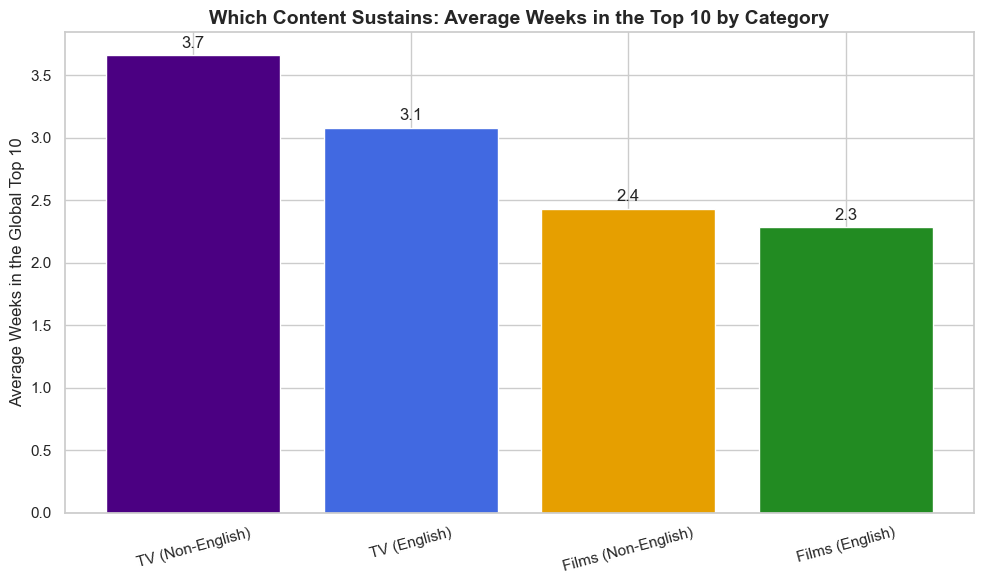

📺 Staying power by category (average weeks and share lasting 5+ weeks):
   TV (Non-English): 3.7 avg weeks, 23.8% lasted 5+ weeks (n = 399)
   TV (English): 3.1 avg weeks, 20.9% lasted 5+ weeks (n = 474)
   Films (Non-English): 2.4 avg weeks, 8.1% lasted 5+ weeks (n = 595)
   Films (English): 2.3 avg weeks, 9.0% lasted 5+ weeks (n = 642)


In [5]:
# Measuring Staying Power by Category
category_stats = (global_titles
                  .assign(is_durable=global_titles['max_weeks'] >= 5)
                  .groupby('category', as_index=False)
                  .agg(mean_weeks=('max_weeks', 'mean'),
                       durable_rate=('is_durable', 'mean'),
                       title_count=('title', 'count'))
                  .sort_values('mean_weeks', ascending=False))
category_stats['durable_rate'] = category_stats['durable_rate'] * 100

# Plotting Average Weeks in the Top 10 by Category
fig, ax = plt.subplots()
colors = category_stats['category'].map(category_colors).fillna('#999999')
bars = ax.bar(category_stats['category'], category_stats['mean_weeks'],
              color=colors, edgecolor='white')
ax.set_title('Which Content Sustains: Average Weeks in the Top 10 by Category')
ax.set_xlabel('')
ax.set_ylabel('Average Weeks in the Global Top 10')
ax.bar_label(bars, fmt='%.1f', padding=3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Narrating the Takeaway
print('📺 Staying power by category (average weeks and share lasting 5+ weeks):')
for _, row in category_stats.iterrows():
    print(f"   {row['category']}: {row['mean_weeks']:.1f} avg weeks, "
          f"{row['durable_rate']:.1f}% lasted 5+ weeks (n = {row['title_count']:,})")

**Takeaway.** Format matters more than anything. Series of either language hold the Top 10 for roughly three to four weeks on average, while films of either language average barely over two. The gap widens at the durable end: about one in four TV titles lasts five weeks or longer, against fewer than one in ten films. Non-English TV is the single most durable category on the platform, at 3.7 average weeks and a 23.8% durability rate, even though it is the smallest category by title count.

### **Visual 4: Do Durable Titles Also Travel?**

Lasting a long time and spreading across many countries are not the same thing, as the telenovela leaders already hinted. This view measures the second dimension, geographic reach, using the country-level data and compares it across the same four categories.

1. From the merged data, average the number of countries each title charted in, grouped by category.
2. Plot average reach by category, mirroring the previous view so duration and reach can be compared directly.
3. Note where reach and duration diverge.

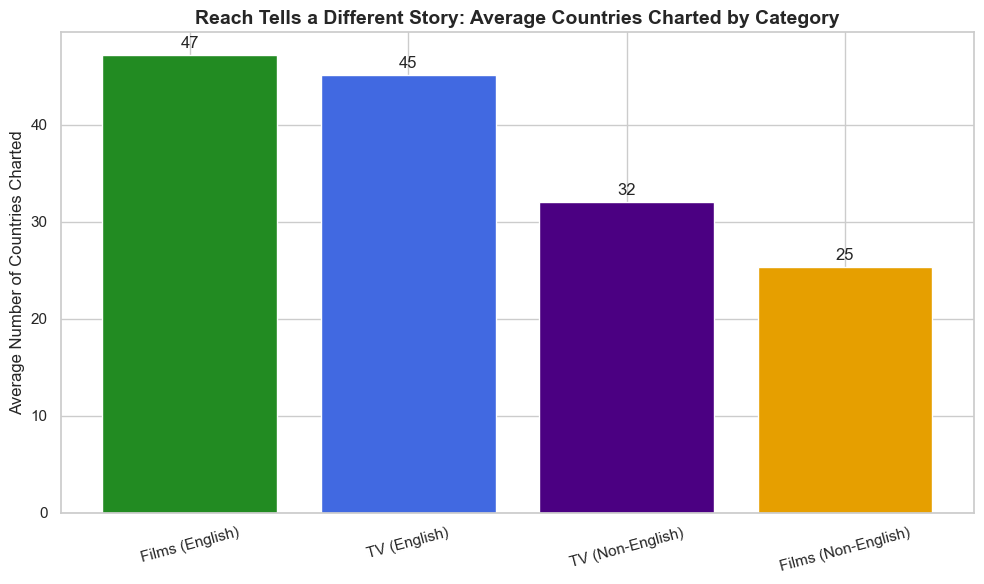

🌍 Average countries charted by category:
   Films (English): 47 countries (n = 642)
   TV (English): 45 countries (n = 473)
   TV (Non-English): 32 countries (n = 399)
   Films (Non-English): 25 countries (n = 581)


In [6]:
# Measuring Average Global Reach by Category
reach_by_category = (reach_vs_longevity
                     .groupby('category', as_index=False)
                     .agg(mean_countries=('countries_charted', 'mean'),
                          title_count=('title', 'count'))
                     .sort_values('mean_countries', ascending=False))

# Plotting Average Countries Charted by Category
fig, ax = plt.subplots()
colors = reach_by_category['category'].map(category_colors).fillna('#999999')
bars = ax.bar(reach_by_category['category'], reach_by_category['mean_countries'],
              color=colors, edgecolor='white')
ax.set_title('Reach Tells a Different Story: Average Countries Charted by Category')
ax.set_xlabel('')
ax.set_ylabel('Average Number of Countries Charted')
ax.bar_label(bars, fmt='%.0f', padding=3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Narrating the Takeaway
print('🌍 Average countries charted by category:')
for _, row in reach_by_category.iterrows():
    print(f"   {row['category']}: {row['mean_countries']:.0f} countries (n = {row['title_count']:,})")

**Takeaway.** Reach runs almost exactly opposite to duration. English titles travel widest, reaching 45 to 47 countries on average, but as visual three showed they rarely last. The non-English content that endures is more concentrated, charting in 25 to 32 countries. The platform faces a tradeoff: English content tends to go wide and brief, while durable non-English content tends to go deep and narrow. The titles worth prizing are the rare ones that escape that tradeoff.

<hr style="page-break-before: always;">

### **Visual 5: The Titles That Do Both**

Visuals three and four revealed a tradeoff: English content goes wide, non-English series go deep. The titles worth chasing are the rare ones that do both. This scatter plots every title's reach against its longevity, with median lines splitting the field into quadrants. The upper right is where durable, widely traveled hits live.

1. Plot countries charted against total weeks in the Top 10 for every title, colored by category.
2. Add median reference lines to mark the four quadrants.
3. Label the standout titles that rank high on both dimensions.

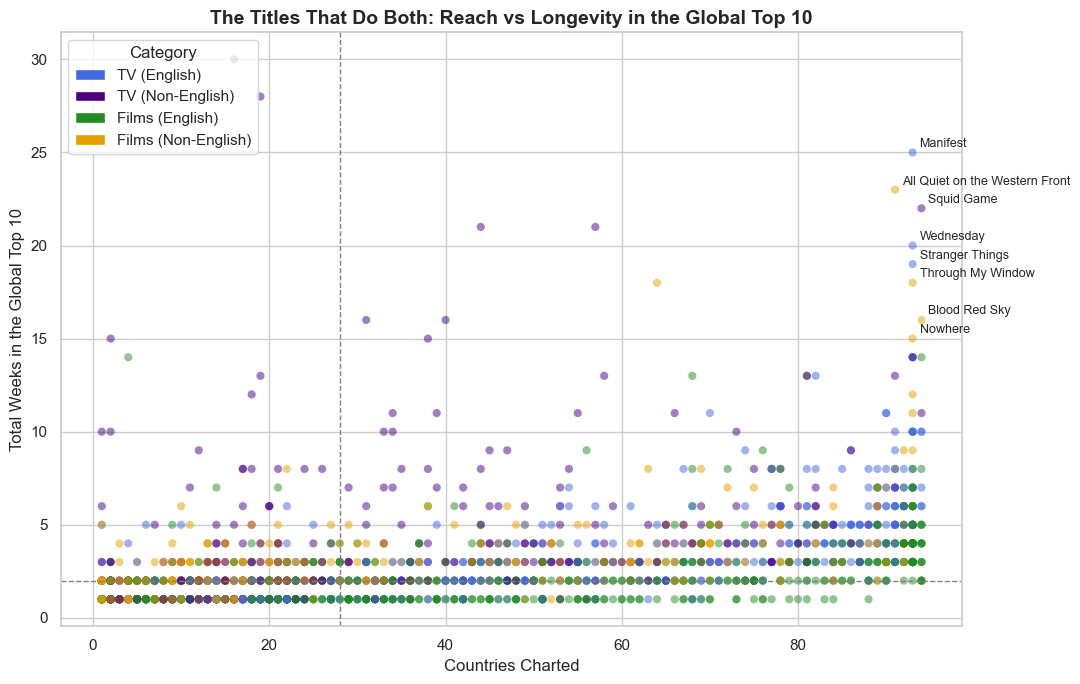

⭐ Titles in the elite upper-right (broad reach and long run):
   Manifest (TV (English)): 25 weeks, 93 countries
   All Quiet on the Western Front (Films (Non-English)): 23 weeks, 91 countries
   Squid Game (TV (Non-English)): 22 weeks, 94 countries
   Wednesday (TV (English)): 20 weeks, 93 countries
   Stranger Things (TV (English)): 19 weeks, 93 countries
   Through My Window (Films (Non-English)): 18 weeks, 93 countries
   Blood Red Sky (Films (Non-English)): 16 weeks, 94 countries
   Nowhere (Films (Non-English)): 15 weeks, 93 countries


In [7]:
from matplotlib.patches import Patch

# Building the Reach vs Longevity View
plot_df = reach_vs_longevity.copy()
plot_df['color'] = plot_df['category'].map(category_colors).fillna('#999999')

weeks_line = plot_df['max_weeks'].median()
countries_line = plot_df['countries_charted'].median()

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(plot_df['countries_charted'], plot_df['max_weeks'],
           c=plot_df['color'], alpha=0.5, edgecolor='none', s=35)

# Drawing Quadrant Reference Lines at the Medians
ax.axvline(countries_line, color='gray', linestyle='--', linewidth=1)
ax.axhline(weeks_line, color='gray', linestyle='--', linewidth=1)

# Labeling the Titles That Do Both (top of the upper-right quadrant)
elite = plot_df[(plot_df['countries_charted'] >= plot_df['countries_charted'].quantile(0.90)) &
                (plot_df['max_weeks'] >= plot_df['max_weeks'].quantile(0.95))]
elite = elite.sort_values('max_weeks', ascending=False).head(8)
for _, row in elite.iterrows():
    ax.annotate(row['show_title'],
                (row['countries_charted'], row['max_weeks']),
                xytext=(5, 4), textcoords='offset points', fontsize=9)

ax.set_title('The Titles That Do Both: Reach vs Longevity in the Global Top 10')
ax.set_xlabel('Countries Charted')
ax.set_ylabel('Total Weeks in the Global Top 10')

# Building the Category Legend
legend_items = [Patch(facecolor=color, label=cat) for cat, color in category_colors.items()]
ax.legend(handles=legend_items, title='Category', loc='upper left')

plt.tight_layout()
plt.show()

# Narrating the Takeaway
print('⭐ Titles in the elite upper-right (broad reach and long run):')
for _, row in elite.iterrows():
    print(f"   {row['show_title']} ({row['category']}): "
          f"{int(row['max_weeks'])} weeks, {int(row['countries_charted'])} countries")

**Takeaway.** Most titles cluster in the lower left, brief and local. The upper-right quadrant, durable and widely traveled, is sparse and valuable, and no single category owns it. The eight standout titles span English series (Manifest, Wednesday, Stranger Things), a non-English series (Squid Game), and non-English films (All Quiet on the Western Front, Through My Window). What they share is not a language but a profile: serialized or franchise-ready stories with cross-border pull, charting in more than ninety countries for fifteen weeks or longer. The longest-running telenovelas sit at the top left instead, durable but concentrated in under twenty countries.

### **Visual 6: The All-Time Ceiling**

Weekly staying power is one lens. The Most Popular list offers the other extreme: the biggest debuts ever, measured by views in a title's first 91 days. This shows where the ceiling sits and which categories reach it.

1. Rank all titles in the Most Popular list by 91-day views.
2. Plot the top twelve as horizontal bars, colored by category.
3. Summarize the category mix at the very top.

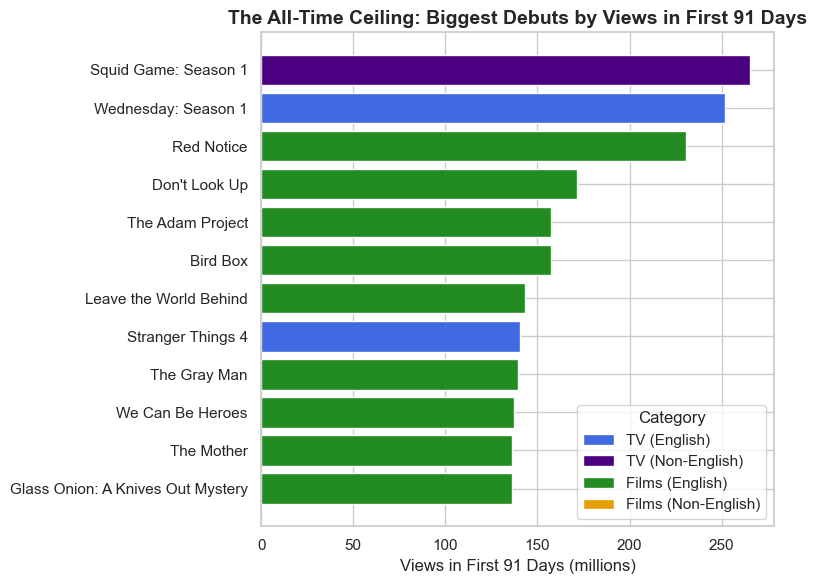

🚀 Category mix among the 12 biggest all-time debuts:
   Films (English): 9
   TV (English): 2
   TV (Non-English): 1


In [8]:
# Selecting the Biggest All-Time Debuts (top 12 by 91-day views)
top_popular = most_popular.sort_values('views_first_91_days', ascending=False).head(12).copy()
top_popular['label'] = top_popular['season_title'].fillna('').astype(str).str.strip()
top_popular['label'] = top_popular['label'].where(top_popular['label'] != '', top_popular['show_title'])
top_popular = top_popular.sort_values('views_first_91_days')
bar_colors = top_popular['category'].map(category_colors).fillna('#999999')

# Plotting the All-Time Viewership Ceiling
fig, ax = plt.subplots(figsize=(8, 6))
views_millions = top_popular['views_first_91_days'] / 1_000_000
bars = ax.barh(top_popular['label'], views_millions, color=bar_colors, edgecolor='white')
ax.set_title('The All-Time Ceiling: Biggest Debuts by Views in First 91 Days')
ax.set_xlabel('Views in First 91 Days (millions)')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

legend_items = [Patch(facecolor=color, label=cat) for cat, color in category_colors.items()]
ax.legend(handles=legend_items, title='Category', loc='lower right')

plt.tight_layout()
plt.show()

# Narrating the Takeaway
print('🚀 Category mix among the 12 biggest all-time debuts:')
for cat, n in top_popular['category'].value_counts().items():
    print(f'   {cat}: {n}')

<hr style="page-break-before: always;">

**Takeaway.** The all-time debut chart is dominated by English-language films: nine of the twelve biggest 91-day launches are English films, from Red Notice to Glass Onion. Yet the two titles at the very top are both series, Squid Game and Wednesday, and they are the same titles that occupied the durable upper-right of visual five. Big film debuts deliver enormous launch-week spikes, but the chart-topping titles that also endure are the cross-border series. Even at the ceiling, lasting value tracks the serialized, widely traveled profile rather than the one-and-done blockbuster.

### **Recommendation**

The six views point to one conclusion. Launch-week volume and staying power are different things, and Netflix's own reporting rewards whoever acts on the difference. Most titles vanish from the Top 10 within two weeks, English films generate the biggest debuts but fade fastest, and the rare titles that are both durable and widely traveled share one profile: serialized or franchise-ready stories with cross-border appeal, such as Squid Game, Wednesday, Stranger Things, and All Quiet on the Western Front.

The recommendation to the content investment committee is to weight green-light and renewal decisions toward that upper-right profile rather than toward the one-week debut spikes that dominate headlines:

- Prioritize renewals and multi-season commitments for series that show early cross-border reach, since longevity compounds far more for serialized content than for film.
- Treat first-week views as a launch signal, not a success metric, and track cumulative weeks in the Top 10 as the measure of durable value.
- Keep investing in non-English series, which sustain longest, while pairing them with the broad-reach mechanics English titles achieve, to pull more titles into the durable, widely traveled quadrant.

The titles already living in that quadrant prove it is reachable. The opportunity is to green-light deliberately for it.

<hr style="page-break-before: always;">

### **Summary Paper**

**Audience.** This story is built for Netflix's content investment committee, an internal, data-fluent group that approves green-light and renewal spending. Because they already know the platform's vocabulary, the briefing uses native terms like views, categories, and weeks in the Top 10 without definition, and focuses on a decision rather than on education.

**Purpose.** The purpose is persuasive, not informational. The briefing argues that launch-week volume and staying power are different things and recommends weighting investment toward titles fitting the durable, widely traveled profile rather than chasing one-week debut spikes. The call to action is stated outright in the closing recommendation.

**Medium.** The medium is a Jupyter notebook exported to PDF and read as an executive briefing. This keeps the narrative, the six visuals, and the underlying code in one consolidated document, which suits a technical stakeholder audience and meets the submission requirement (Netflix, n.d.).

**Design.** Color is consistent and meaningful: one colorblind-safe palette maps each content category to a single color across every chart, so the legend is learned once. The charts progress from a wide distribution, to ranked bars, to a two-dimensional scatter, matching increasing analytical depth. Axes use commas rather than scientific notation, titles state the takeaway in plain language, and no axis is truncated to exaggerate differences.

**Ethical considerations.** All three datasets come directly from Netflix's official Top 10 site, so the data is first-party and was acquired ethically through public release rather than scraping (Netflix, n.d.). It contains no personal information and carries no obvious legal restriction beyond Netflix's terms. The transformations are disclosed rather than hidden. Per-week rows were collapsed to one row per title using each title's maximum cumulative weeks, and titles were keyed on season where Netflix tracks one. The reach-versus-longevity scatter uses an inner join, so it includes only titles appearing in both the global and country files, and that limit is stated. The main risks are interpretive: cumulative weeks favors older titles that have had more time to accumulate, average weeks is sensitive to a few long-running outliers, and country reach reflects only Netflix's selected reporting territories. These are mitigated by reporting medians, means, and durability rates together, by labeling every filter, and by noting that Netflix's figures are self-reported and not independently audited.

<div style="border: 5px solid black; padding: 20px; border-radius: 6px;">

# Reflection for Week 1

## General Reflection

This first assignment felt like a really clean bridge between technical analysis and storytelling. Working with the three Netflix Top 10 datasets forced me to think beyond “what’s interesting in the data?” and instead ask, “what would actually matter to a decision-maker who lives with this data every week?” Framing the work around the content investment committee helped anchor every visual to a concrete question: what separates a flash-in-the-pan title from one that quietly compounds value over time?

I liked that the notebook became both a technical artifact and an executive briefing. The structure—setup, preparation, six visuals, then a recommendation—made the story feel intentional instead of like a random tour of charts. The most satisfying part was seeing the narrative arc emerge: staying power is rare, certain content types sustain better, reach and duration trade off, and a small set of titles break that tradeoff and define the “upper-right” profile worth chasing.

## Straightforward Aspects

- **Using Python and pandas:**  
  The data wrangling itself felt comfortable—groupbys, merges, aggregations, and creating a unified title key were all familiar patterns.

- **Designing the visuals:**  
  Choosing a colorblind-safe palette, consistent figure sizing, and clear titles/labels came naturally and aligned with what I’ve been learning about good visualization practice.

- **Defining audience, purpose, and medium:**  
  Once I chose the content investment committee as the audience, it was easy to justify the Jupyter notebook as a technical briefing and to keep the language data-fluent but concise.

- **Crafting the call to action:**  
  Recommending that Netflix prioritize serialized, cross-border, durable titles over one-week spikes flowed logically from the visuals and felt like a natural conclusion rather than something bolted on.

## Challenging Aspects

- **Balancing detail with clarity in the narrative:**  
  It was tricky to decide how much statistical nuance to include without cluttering the story. For example, I had to resist the urge to overload the text with extra metrics when the median and a few key percentages already carried the point.

- **Choosing the “right” summary statistics:**  
  The distributions were skewed, so medians, means, and thresholds (like 5+ or 10+ weeks) all told slightly different stories. Deciding which to foreground for each visual took some thought.

- **Connecting all six visuals into one coherent arc:**  
  Making sure each visual felt like a deliberate step toward the final recommendation—not just six interesting charts—required revisiting titles, subtitles, and takeaways multiple times.

- **Ethical and methodological transparency:**  
  Being explicit about Netflix’s metric change (hours to views), the self-reported nature of the data, and the limitations of country coverage added complexity. It was a challenge to acknowledge those caveats without derailing the main narrative.
